# Sprint 2: Storage, Cleaning, and Preprocessing

This notebook builds a SQL metadata database for the ASL Alphabet dataset, validates image files, assigns train/validation/test splits, and prepares the dataset for preprocessing.

In [41]:
import os
import sqlite3
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split

TRAIN_DIR = "../data/asl_alphabet_train/asl_alphabet_train"
TEST_DIR = "../data/asl_alphabet_test"
DB_PATH = "../asl_metadata.db"

print(os.path.exists(TRAIN_DIR))
print(os.listdir(TRAIN_DIR)[:10])

True
['.DS_Store', 'R', 'U', 'I', 'N', 'G', 'Z', 'T', 'S', 'A']


Dataset image files are stored locally in the ignored data/ folder, while the notebook stores relative image paths in SQLite so the workflow can be reproduced across team members’ machines.

## SQL Database Connection

SQLite is used to store image metadata, including relative file paths, labels, validation status, and split assignments.

In [43]:
conn = sqlite3.connect(DB_PATH)

## Build Image Metadata

This section scans the training image folders and creates one metadata record per image.
The database stores relative paths so the notebook can run on different machines.

In [44]:
records = []

for label in os.listdir(TRAIN_DIR):
    if label.startswith("."):
        continue

    class_path = os.path.join(TRAIN_DIR, label)

    if os.path.isdir(class_path):
        for image_file in os.listdir(class_path):
            if image_file.startswith("."):
                continue

            image_path = os.path.join(class_path, image_file)
            relative_path = os.path.relpath(image_path, TRAIN_DIR)

            records.append({
                "file_path": relative_path,
                "label": label
            })

df = pd.DataFrame(records)
df.head()

,file_path,label
0,R/R2837.jpg,R
1,R/R2189.jpg,R
2,R/R1480.jpg,R
3,R/R1494.jpg,R
4,R/R2823.jpg,R


## Image Cleaning and Validation

Each image is opened with PIL to confirm it can be loaded. The notebook records width, height, file format, validity status, and any issue notes.

In [45]:
widths = []
heights = []
formats = []
is_valids = []
issue_notes = []

for path in df["file_path"]:
    full_path = os.path.join(TRAIN_DIR, path)

    try:
        with Image.open(full_path) as img:
            img.load()
            widths.append(img.width)
            heights.append(img.height)
            formats.append(img.format)
            is_valids.append(1)
            issue_notes.append(None)
    except Exception as e:
        widths.append(None)
        heights.append(None)
        formats.append(None)
        is_valids.append(0)
        issue_notes.append(str(e))

df["width"] = widths
df["height"] = heights
df["file_format"] = formats
df["is_valid"] = is_valids
df["issue_notes"] = issue_notes

## Train, Validation, and Test Splits

The dataset is split using a stratified 70/15/15 split to preserve class balance across all classes.

In [46]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

df["split"] = "unassigned"
df.loc[train_df.index, "split"] = "train"
df.loc[val_df.index, "split"] = "val"
df.loc[test_df.index, "split"] = "test"

## Saving Metadata to SQLite

The completed metadata table is saved to SQLite for later querying by the preprocessing pipeline.

In [47]:
conn.execute("DROP TABLE IF EXISTS images")

conn.execute("""
CREATE TABLE images (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    file_path TEXT NOT NULL UNIQUE,
    label TEXT NOT NULL,
    width INTEGER,
    height INTEGER,
    file_format TEXT,
    is_valid INTEGER NOT NULL,
    issue_notes TEXT,
    split TEXT NOT NULL CHECK(split IN ('train', 'val', 'test'))
)
""")

df.to_sql("images", conn, if_exists="append", index=False)

conn.execute("CREATE INDEX IF NOT EXISTS idx_images_split ON images(split)")
conn.execute("CREATE INDEX IF NOT EXISTS idx_images_label ON images(label)")
conn.execute("CREATE INDEX IF NOT EXISTS idx_images_valid ON images(is_valid)")

conn.commit()

## SQL Verification

These queries confirm that the database contains the expected image records, valid files, and balanced split assignments.

In [48]:
pd.read_sql_query("""
SELECT split, COUNT(*) AS count
FROM images
GROUP BY split
""", conn)

,split,count
0,test,13050
1,train,60900
2,val,13050


In [49]:
pd.read_sql_query("""
SELECT label, split, COUNT(*) AS count
FROM images
GROUP BY label, split
ORDER BY label, split
""", conn)

,label,split,count
0,A,test,450
1,A,train,2100
2,A,val,450
3,B,test,450
4,B,train,2100
...,...,...,...
82,nothing,train,2100
83,nothing,val,450
84,space,test,450
85,space,train,2100


In [50]:
pd.read_sql_query("""
SELECT is_valid, COUNT(*) AS count
FROM images
GROUP BY is_valid
""", conn)

,is_valid,count
0,1,87000


In [51]:
pd.read_sql_query("""
SELECT width, height, COUNT(*) AS count
FROM images
GROUP BY width, height
""", conn)

,width,height,count
0,200,200,87000


## Loading Split DataFrames from SQL

The train, validation, and test splits are loaded from SQL into Pandas DataFrames. These DataFrames will be passed into the preprocessing pipeline and PyTorch Dataset class.

In [52]:
train_df = pd.read_sql_query("""
SELECT file_path, label
FROM images
WHERE split = 'train'
AND is_valid = 1
""", conn)

val_df = pd.read_sql_query("""
SELECT file_path, label
FROM images
WHERE split = 'val'
AND is_valid = 1
""", conn)

test_df = pd.read_sql_query("""
SELECT file_path, label
FROM images
WHERE split = 'test'
AND is_valid = 1
""", conn)

train_df.shape, val_df.shape, test_df.shape

((60900, 2), (13050, 2), (13050, 2))

In [53]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(60900, 2)
(13050, 2)
(13050, 2)


In [54]:
train_df.head()

,file_path,label
0,R/R2189.jpg,R
1,R/R1480.jpg,R
2,R/R1494.jpg,R
3,R/R228.jpg,R
4,R/R200.jpg,R


## Summary

This section created a SQLite metadata database for the ASL Alphabet dataset. Each image record includes a relative file path, class label, image dimensions, file format, validation status, and train/validation/test split assignment.

A stratified 70/15/15 split was used to preserve class balance. The database can now be queried to retrieve clean image records for preprocessing and model training.

## Ticket 4: Custom Dataset, DataLoader & Verification (Nick)

This section builds the PyTorch Dataset and DataLoader pipeline using the validated image metadata stored in the SQLite `images` table.

### 1. Import PyTorch and Visualization Libraries

We import the tools needed to load images, create a custom PyTorch Dataset, create DataLoaders, and visualize sample batches.


In [55]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt


ModuleNotFoundError: No module named 'torch'

### 2. Load Valid Image Metadata from SQL

We load only valid image records from the `images` table and keep the file path, label, and assigned split.

In [56]:
metadata_df = pd.read_sql_query("""
SELECT file_path, label, split
FROM images
WHERE is_valid = 1
""", conn)

metadata_df.head()


,file_path,label,split
0,R/R2837.jpg,R,test
1,R/R2189.jpg,R,train
2,R/R1480.jpg,R,train
3,R/R1494.jpg,R,train
4,R/R2823.jpg,R,test


### 3. Verify Metadata Before Building the Dataset

We check the split distribution, class distribution, and missing values to confirm that the metadata is ready for DataLoader creation.

In [27]:
# Check number of images per split
print("Split counts:")
print(metadata_df["split"].value_counts())

# Check for missing values
print("\nMissing values:")
print(metadata_df.isnull().sum())

print("\nNumber of classes:", metadata_df["label"].nunique())


Split counts:
split
train    60900
test     13050
val      13050
Name: count, dtype: int64

Missing values:
file_path    0
label        0
split        0
dtype: int64

Number of classes: 29


In [15]:
# Check class balance across train, validation, and test sets
pd.crosstab(metadata_df["label"], metadata_df["split"])

split,test,train,val
label,,,
A,450,2100,450
B,450,2100,450
C,450,2100,450
D,450,2100,450
E,450,2100,450
F,450,2100,450
G,450,2100,450
H,450,2100,450
I,450,2100,450


### 4. Create Label Mapping

PyTorch models require numeric labels, so each ASL class label is converted into an integer.

In [23]:
# Create sorted list of unique labels
classes = sorted(metadata_df["label"].unique())

# Convert label names to numbers
class_to_idx = {class_name: idx for idx, class_name in enumerate(classes)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

class_to_idx

{'A': 0,
 'B': 1,
 'C': 2,
 'D': 3,
 'E': 4,
 'F': 5,
 'G': 6,
 'H': 7,
 'I': 8,
 'J': 9,
 'K': 10,
 'L': 11,
 'M': 12,
 'N': 13,
 'O': 14,
 'P': 15,
 'Q': 16,
 'R': 17,
 'S': 18,
 'T': 19,
 'U': 20,
 'V': 21,
 'W': 22,
 'X': 23,
 'Y': 24,
 'Z': 25,
 'del': 26,
 'nothing': 27,
 'space': 28}

### 5. Define Image Transforms

Training data uses light augmentation, while validation and test data use consistent resizing and normalization for fair evaluation.

In [25]:
# Transform for training data
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Transform for validation and testing data
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


### 6. Create Custom PyTorch Dataset Class

The custom Dataset class loads one image and one label at a time from the SQL metadata output, applies transforms, and returns tensors for model training.

In [18]:
class ASLDataset(Dataset):
    def __init__(self, dataframe, class_to_idx, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = row["file_path"]
        label_name = row["label"]
        label = self.class_to_idx[label_name]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


### 7. Split Metadata into Train, Validation, and Test DataFrames

We separate the metadata by split before creating Dataset objects and DataLoaders.

In [28]:
# Separate metadata by split
train_df = metadata_df[metadata_df["split"] == "train"]
val_df = metadata_df[metadata_df["split"] == "val"]
test_df = metadata_df[metadata_df["split"] == "test"]

print("Train records:", len(train_df))
print("Validation records:", len(val_df))
print("Test records:", len(test_df))

Train records: 60900
Validation records: 13050
Test records: 13050


#### Prepends the correct dataset root folder to each relative image path so PyTorch can locate and load the files.

In [50]:
from pathlib import Path

# Root folder where all ASL image class folders are stored
DATA_ROOT = Path("../data/asl_alphabet_train/asl_alphabet_train")

# Make a copy so we don't modify the original split DataFrames accidentally
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

# Add the real dataset folder path to each relative file path
train_df["file_path"] = train_df["file_path"].apply(lambda x: str(DATA_ROOT / x))
val_df["file_path"] = val_df["file_path"].apply(lambda x: str(DATA_ROOT / x))
test_df["file_path"] = test_df["file_path"].apply(lambda x: str(DATA_ROOT / x))

### 8. Create Dataset Objects

Each split gets its own Dataset object so training, validation, and testing remain separate.

In [56]:
train_dataset = ASLDataset(train_df, class_to_idx, transform=train_transform)
val_dataset = ASLDataset(val_df, class_to_idx, transform=eval_transform)
test_dataset = ASLDataset(test_df, class_to_idx, transform=eval_transform)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 60900
Validation dataset size: 13050
Test dataset size: 13050


### 9. Configure Batch Size and Num Workers

Batch size controls how many images are loaded at once. `num_workers = 0` is recommended for Jupyter notebooks on Mac to avoid multiprocessing issues.

In [58]:
batch_size = 32
num_workers = 0     # Use 0 for Mac/Jupyter to avoid multiprocessing issues

### 10. Create DataLoaders

DataLoaders prepare batches of images and labels for model training, validation, and testing.

In [59]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)

### 11. Verify One Batch
This confirms that the DataLoader returns batches correctly, with images shaped as batch size, color channels, height, and width.

In [60]:
# Get one batch from the training DataLoader
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image tensor type:", images.dtype)
print("Label tensor type:", labels.dtype)
print("Sample labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image tensor type: torch.float32
Label tensor type: torch.int64
Sample labels: tensor([18,  7, 16,  6, 23, 12,  4, 11, 20, 26])


### 12. Visualize Sample Batch
Visualizing a batch confirms that images load correctly and labels match the expected ASL classes.

In [61]:
def unnormalize_image(image_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    image_tensor = image_tensor * std + mean
    image_tensor = torch.clamp(image_tensor, 0, 1)

    return image_tensor

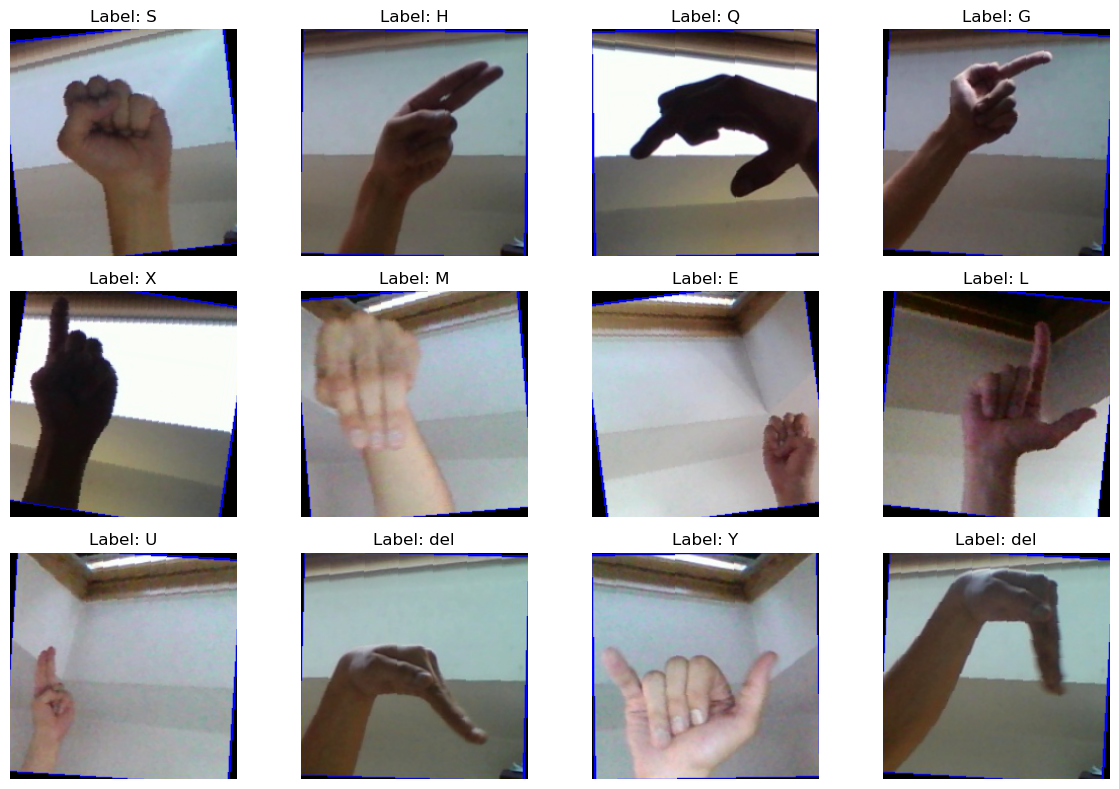

In [62]:
# Visualize sample images from one batch
plt.figure(figsize=(12, 8))

for i in range(12):
    image = unnormalize_image(images[i])
    image = image.permute(1, 2, 0)

    label_idx = labels[i].item()
    label_name = idx_to_class[label_idx]

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(f"Label: {label_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### 13. Final Verification Summary
The final verification confirms that the Dataset and DataLoader pipeline is ready for Sprint 3 model training.

In [63]:
print("DataLoader Verification Summary")
print("- Train batches:", len(train_loader))
print("- Validation batches:", len(val_loader))
print("- Test batches:", len(test_loader))
print("- Batch size:", batch_size)
print("- Number of classes:", len(classes))
print("- Image shape:", images.shape)
print("- Label shape:", labels.shape)

DataLoader Verification Summary
- Train batches: 1904
- Validation batches: 408
- Test batches: 408
- Batch size: 32
- Number of classes: 29
- Image shape: torch.Size([32, 3, 224, 224])
- Label shape: torch.Size([32])


### Ticket 4 Summary

For this task, I created a custom PyTorch Dataset class that loads ASL images and labels from the metadata output. I applied separate transforms for training and evaluation, then created DataLoaders for the train, validation, and test splits. I verified that image batches load successfully, labels are correctly assigned, and batch dimensions match the expected model input format. A sample batch was also visualized to confirm that images and labels are properly connected.

In [36]:
conn.close()